# Chapter 17 - Structural Breaks

## Preparation

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import random

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
from scipy.stats import norm, moment
import statsmodels.api as sm

from utils.sampling_bars import dollar_bar
from utils.structural_break import (
    bde_recursive_residual_cusum,
    chow_type_dickey_fuller_test,
    csw_cusum_test,
    supremum_adf_test,
)

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

data_path = '../data/processed/clean_IVE_tickbidask.parq'
df = pd.read_parquet(data_path)

dollar_bars = dollar_bar(df)

In [2]:
dollar_bars.head()

,price,bid,ask,vol,dollar_vol,trade_count,price_high,price_low
date,,,,,,,,
2009-09-28 09:31:50,50.75,50.73,50.76,300.0,15225.00,1.0,50.75,50.75
2009-09-28 09:33:02,50.81,50.80,50.81,800.0,40648.00,2.0,50.81,50.81
2009-09-28 09:34:04,50.82,50.80,50.82,100.0,5082.00,1.0,50.82,50.82
2009-09-28 09:38:28,50.81,50.79,50.81,195.0,9907.95,1.0,50.81,50.81
2009-09-28 09:42:17,50.85,50.83,50.85,200.0,10170.00,2.0,50.85,50.85


<Axes: xlabel='date'>

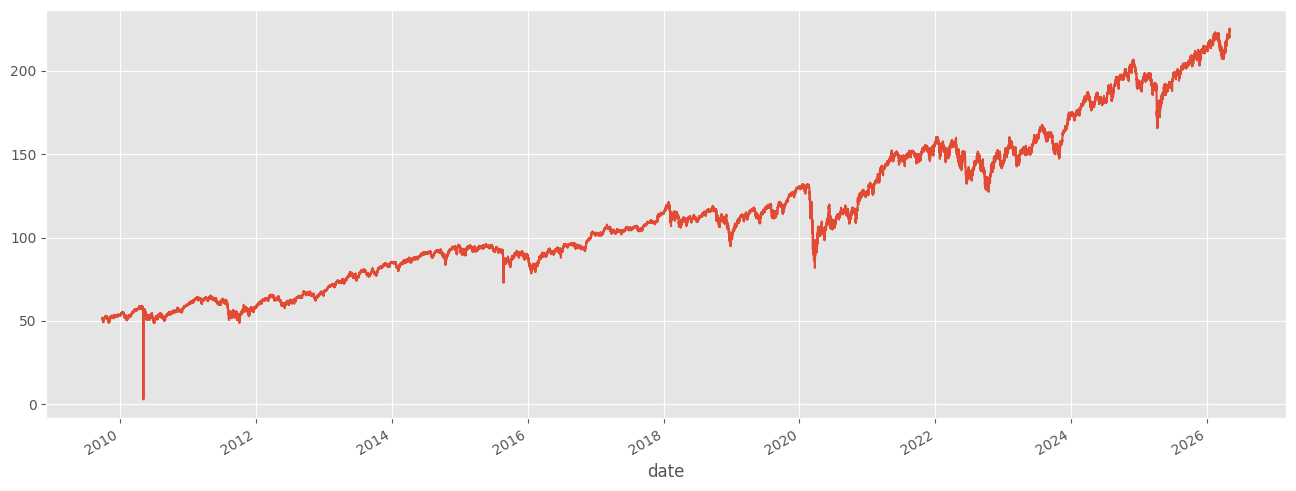

In [3]:
dollar_bars["price"].plot()

## 1. On a dollar bar series on E-mini S&P 500 futures,

### a. Apply the Brown-Durbin-Evans method. Does it recognize the dot-com bubble?

Note: the local file loaded in this notebook is IVE tick data beginning in 2009, not E-mini S&P 500 futures covering the dot-com period. The code below checks the mechanics of the BDE recursive-residual CUSUM test on the available sample; it cannot answer the dot-com-bubble question from this data.

In [4]:
# Log prices and returns
dollar_bars['log_price'] = np.log(dollar_bars['price'])
dollar_bars['log_ret'] = dollar_bars['log_price'].diff()
dollar_bars['log_t1'] = dollar_bars['log_ret'].shift(1)

# Prevent look-ahead bias: momentum uses prices available before the current return.
shifted_price = dollar_bars['price'].shift(1)
dollar_bars['mom2'] = shifted_price.pct_change(periods=2)
dollar_bars['mom5'] = shifted_price.pct_change(periods=5)

# Volatility
dollar_bars['volatility_15'] = dollar_bars['log_t1'].rolling(window=15, min_periods=15).std()
dollar_bars['volatility_50'] = dollar_bars['log_t1'].rolling(window=50, min_periods=50).std()

# Serial correlation. This is equivalent to rolling.apply(lambda x: x.autocorr(lag)),
# but avoids a very slow Python callback for every rolling window.
def rolling_autocorr(series, window, lag):
    if lag <= 0 or lag >= window:
        raise ValueError('lag must be positive and smaller than window')
    pair_window = window - lag
    return series.rolling(window=pair_window, min_periods=pair_window).corr(series.shift(lag))

window_autocorr = 100
dollar_bars['autocorr_2'] = rolling_autocorr(dollar_bars['log_t1'], window_autocorr, lag=2)
dollar_bars['autocorr_4'] = rolling_autocorr(dollar_bars['log_t1'], window_autocorr, lag=4)

In [5]:
feature_cols = ['volatility_50', 'volatility_15', 'autocorr_2', 'autocorr_4', 'mom2', 'mom5']
test_data = dollar_bars[['price', 'log_price', 'log_ret', *feature_cols]].dropna()

print(f'Test sample: {test_data.index.min()} to {test_data.index.max()}')
print(f'Number of dollar bars in test sample: {len(test_data):,}')

Test sample: 2009-09-28 11:30:52 to 2026-05-01 16:00:00
Number of dollar bars in test sample: 1,443,590


In [6]:
# Use a non-trivial initial estimation window so the recursive model is not seeded
# by only one barely identified regression fit. The crossing date is still a CUSUM
# boundary event, not a timestamp where price itself must jump.
initial_observations = max(len(feature_cols) + 1, 10_000)
initial_observations = min(initial_observations, len(test_data) - 2)

bde = bde_recursive_residual_cusum(
    y=test_data['log_ret'],
    X=test_data[feature_cols],
    initial=initial_observations,
    conf_level=0.95,
    add_intercept=True,
)

In [7]:
print(f'Reject stability: {bde.attrs["reject"]}')
print(f'First crossing: {bde.attrs["first_crossing"]}')
print(f'Initial observations: {bde.attrs["initial_observations"]:,}')
print(f'Initial window ends: {test_data.index[bde.attrs["initial_observations"] - 1]}')
print(f'Recursive residual mean: {bde.attrs["recursive_resid_mean"]:.3e}')
print(f'Recursive residual std: {bde.attrs["sigma_hat"]:.3e}')

Reject stability: True
First crossing: 2014-02-19 10:18:12
Initial observations: 10,000
Initial window ends: 2009-12-17 12:08:41
Recursive residual mean: 1.532e-05
Recursive residual std: 3.288e-03


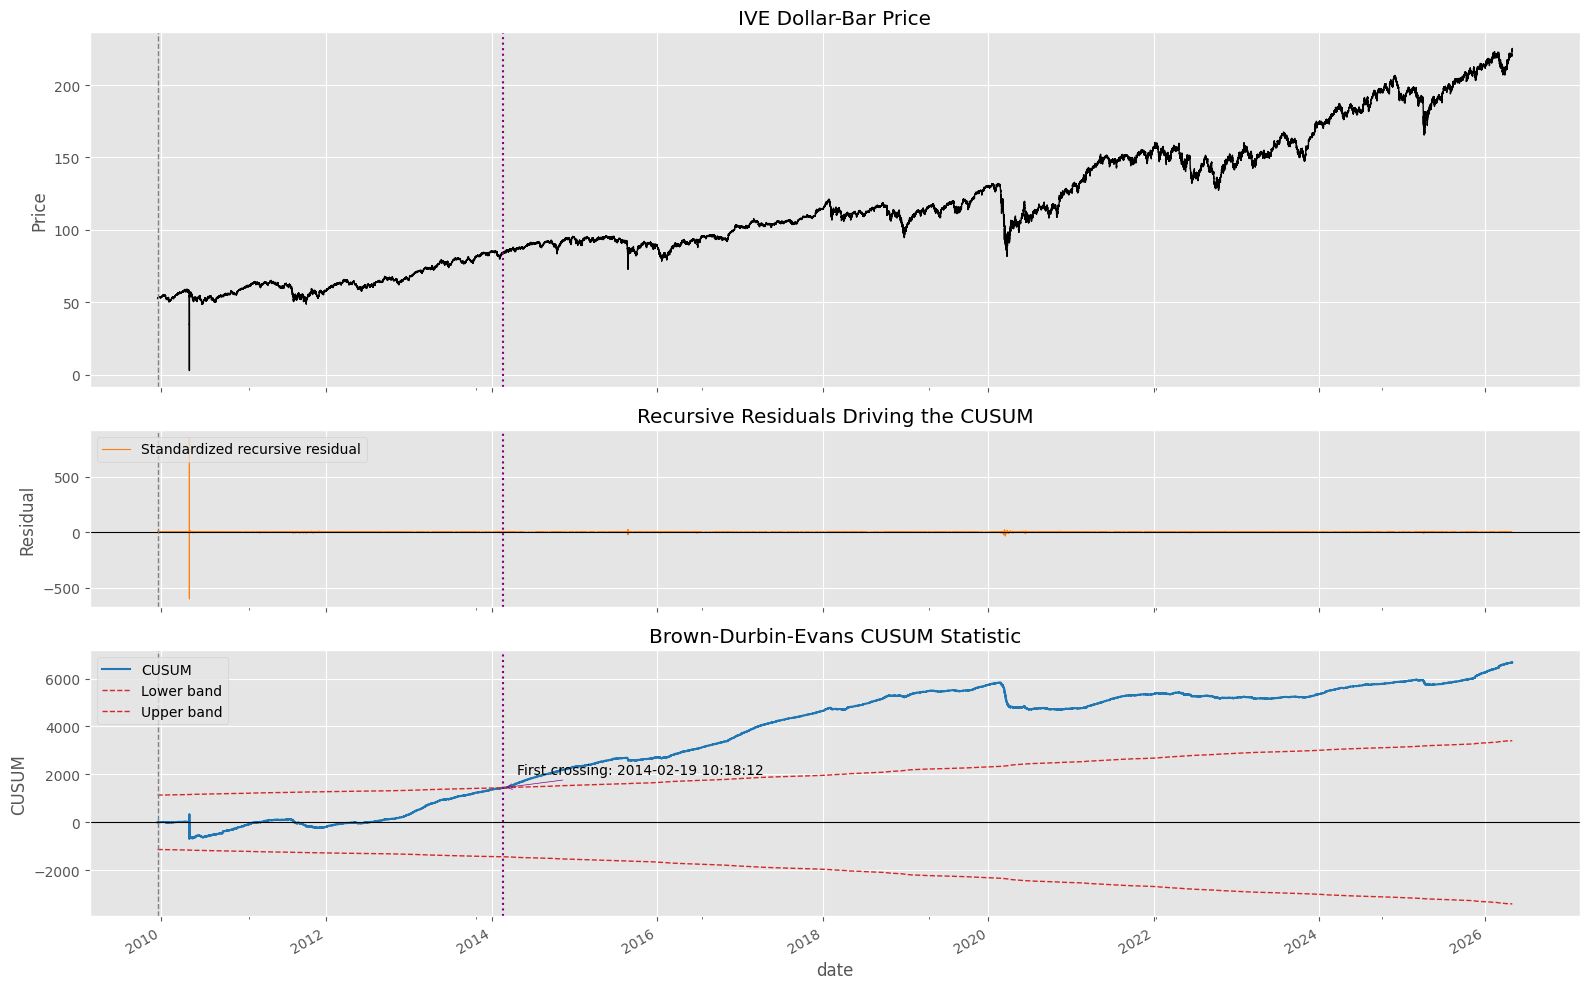

In [8]:
plot_df = bde.join(test_data[['price', 'log_ret']], how='left')
first_crossing = bde.attrs['first_crossing']
initial_end = test_data.index[bde.attrs['initial_observations'] - 1]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(16, 10),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1, 1.5]},
)

plot_df['price'].plot(ax=axes[0], color='black', linewidth=1)
axes[0].set_title('IVE Dollar-Bar Price')
axes[0].set_ylabel('Price')

plot_df['std_recursive_resid'].plot(ax=axes[1], color='tab:orange', linewidth=0.8, label='Standardized recursive residual')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Recursive Residuals Driving the CUSUM')
axes[1].set_ylabel('Residual')
axes[1].legend(loc='upper left')

plot_df['cusum'].plot(ax=axes[2], color='tab:blue', linewidth=1.5, label='CUSUM')
plot_df['lower'].plot(ax=axes[2], color='tab:red', linestyle='--', linewidth=1, label='Lower band')
plot_df['upper'].plot(ax=axes[2], color='tab:red', linestyle='--', linewidth=1, label='Upper band')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Brown-Durbin-Evans CUSUM Statistic')
axes[2].set_ylabel('CUSUM')
axes[2].legend(loc='upper left')

for ax in axes:
    ax.axvline(initial_end, color='gray', linewidth=1, linestyle='--')

if first_crossing is not None:
    for ax in axes:
        ax.axvline(first_crossing, color='purple', linewidth=1.5, linestyle=':')
    axes[2].annotate(
        f'First crossing: {first_crossing}',
        xy=(first_crossing, plot_df.loc[first_crossing, 'cusum']),
        xytext=(10, 10),
        textcoords='offset points',
        arrowprops={'arrowstyle': '->', 'color': 'purple'},
    )

plt.tight_layout()
plt.show()

### b. Apply the Chu-Stinchcombe-White method. Does it find a bubble in  2007–2008?

Note: the local IVE sample starts in 2009, so it cannot test for a 2007–2008 bubble. The code below applies the CSW statistic to daily closes from the available sample.

Reject one-sided CSW: True
First crossing: 2010-05-10 00:00:00
Observations: 4,174


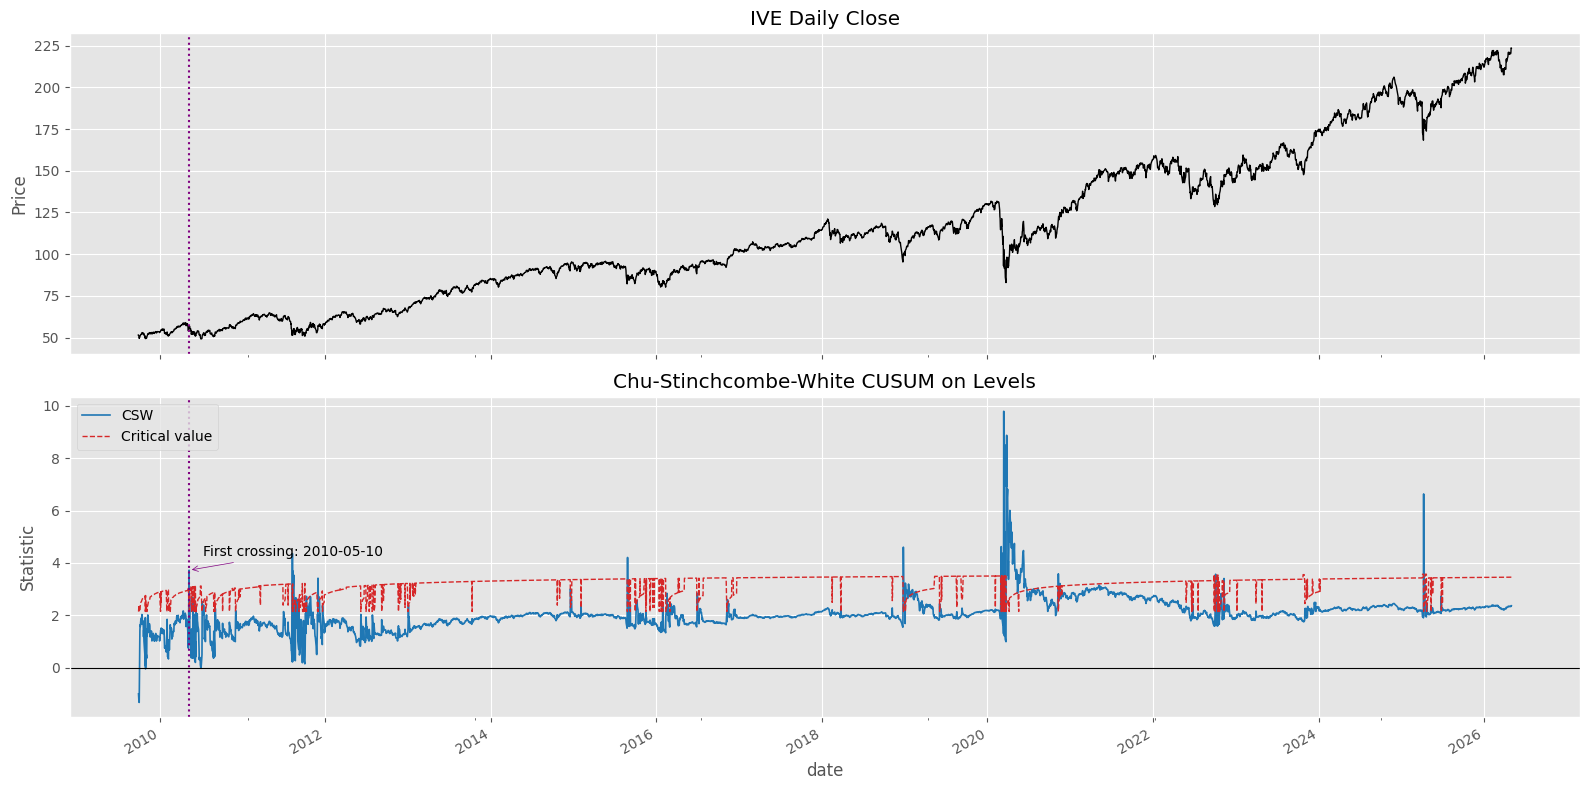

In [9]:
csw_data = test_data[['price', 'log_price']].resample('1D').last().dropna()
csw = csw_cusum_test(csw_data['log_price'])

print(f'Reject one-sided CSW: {csw.attrs["reject"]}')
print(f'First crossing: {csw.attrs["first_crossing"]}')
print(f'Observations: {csw.attrs["nobs"]:,}')

csw_plot_df = csw.join(csw_data[['price']], how='left')
first_csw_crossing = csw.attrs['first_crossing']

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

csw_plot_df['price'].plot(ax=axes[0], color='black', linewidth=1)
axes[0].set_title('IVE Daily Close')
axes[0].set_ylabel('Price')

csw_plot_df['csw'].plot(ax=axes[1], color='tab:blue', linewidth=1.2, label='CSW')
csw_plot_df['critical'].plot(ax=axes[1], color='tab:red', linestyle='--', linewidth=1, label='Critical value')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Chu-Stinchcombe-White CUSUM on Levels')
axes[1].set_ylabel('Statistic')
axes[1].legend(loc='upper left')

if first_csw_crossing is not None:
    for ax in axes:
        ax.axvline(first_csw_crossing, color='purple', linewidth=1.5, linestyle=':')
    axes[1].annotate(
        f'First crossing: {first_csw_crossing.date()}',
        xy=(first_csw_crossing, csw_plot_df.loc[first_csw_crossing, 'csw']),
        xytext=(10, 10),
        textcoords='offset points',
        arrowprops={'arrowstyle': '->', 'color': 'purple'},
    )

plt.tight_layout()
plt.show()

## 2. On a dollar bar series on E-mini S&P 500 futures,

### a. Compute the SDFC (Chow-type) explosiveness test. What break date does this method select? Is this what you expected?

Note: this notebook uses the local IVE dollar-bar sample, not E-mini S&P 500 futures. The selected break date below answers the available-sample mechanics rather than the original futures-data framing.

SDFC statistic: 0.3548
Selected break date: 2020-03-23 15:36:07
Selected break location: 783512 (54.27% of sample)
Sample size: 1,443,691
Trim fraction: 15%


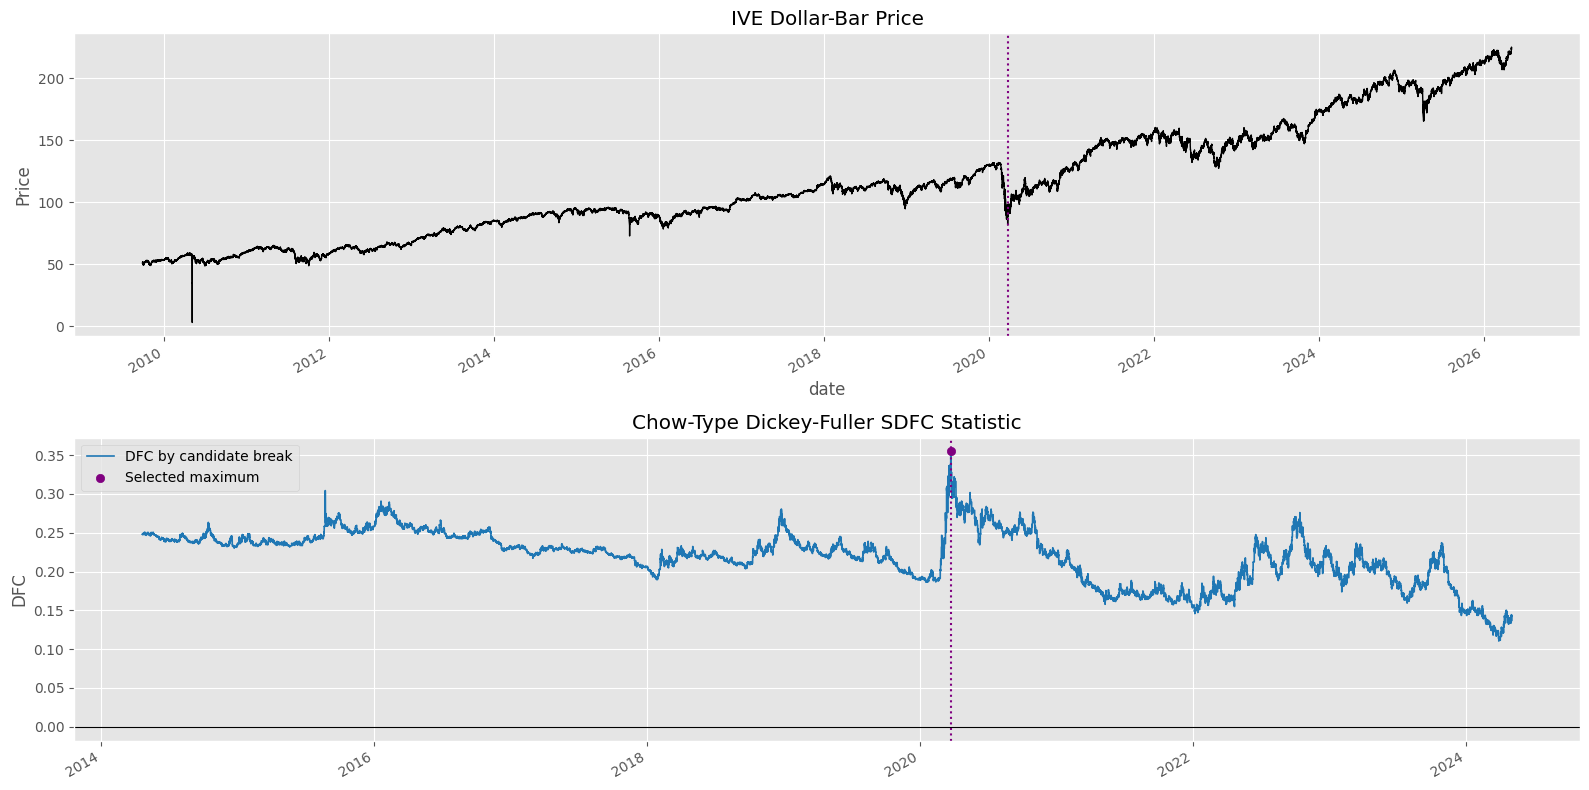

In [10]:
sdfc = chow_type_dickey_fuller_test(dollar_bars["log_price"].dropna(), min_fraction=0.15)
selected_row = sdfc[sdfc['selected']].iloc[0]
selected_break = sdfc.attrs['break_date']

print(f'SDFC statistic: {sdfc.attrs["sdfc"]:.4f}')
print(f'Selected break date: {selected_break}')
print(f'Selected break location: {sdfc.attrs["break_loc"]} ({selected_row["tau"]:.2%} of sample)')
print(f'Sample size: {sdfc.attrs["nobs"]:,}')
print(f'Trim fraction: {sdfc.attrs["min_fraction"]:.0%}')

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

dollar_bars['price'].plot(ax=axes[0], color='black', linewidth=1)
axes[0].axvline(selected_break, color='purple', linewidth=1.5, linestyle=':')
axes[0].set_title('IVE Dollar-Bar Price')
axes[0].set_ylabel('Price')

sdfc['dfc'].plot(ax=axes[1], color='tab:blue', linewidth=1.2, label='DFC by candidate break')
axes[1].scatter([selected_break], [selected_row['dfc']], color='purple', zorder=3, label='Selected maximum')
axes[1].axvline(selected_break, color='purple', linewidth=1.5, linestyle=':')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Chow-Type Dickey-Fuller SDFC Statistic')
axes[1].set_ylabel('DFC')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

### b. Compute and plot the SADF values for this series. Do you observe extreme spikes around the dot-com bubble and before the Great Recession? Did the bursts also cause spikes?

Note: this notebook's local IVE sample starts on 2009-09-28. It cannot test the dot-com bubble or the pre-Great-Recession period without a longer dataset.

In [ ]:
sadf_data = test_data[['price', 'log_price']].resample('1D').last().dropna()

sadf_lags = 1
sadf_min_length = max(30, round(0.05 * len(sadf_data)))
sadf = supremum_adf_test(
    sadf_data['log_price'],
    min_length=sadf_min_length,
    lags=sadf_lags,
)

max_sadf_date = sadf['sadf'].idxmax()
max_sadf_row = sadf.loc[max_sadf_date]
max_sadf_value = max_sadf_row['sadf']
max_sadf_start = max_sadf_row['start']
max_sadf_nobs = int(max_sadf_row['nobs'])

print(f'SADF maximum: {max_sadf_value:.4f}')
print(f'Maximum date: {max_sadf_date.date()}')
print(f'Window start at maximum: {max_sadf_start}')
print(f'Window observations at maximum: {max_sadf_nobs:,}')
print(f'Lags: {sadf.attrs["lags"]}')
print(f'Minimum ADF window length: {sadf.attrs["min_length"]:,}')
print(f'Daily sample: {sadf_data.index.min().date()} to {sadf_data.index.max().date()} ({len(sadf_data):,} observations)')
print('The local sample starts after the dot-com bubble and after the 2007-2009 Great Recession, so those book-period spikes require a longer dataset.')

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

sadf_data['price'].plot(ax=axes[0], color='black', linewidth=1)
axes[0].axvline(max_sadf_date, color='purple', linewidth=1.5, linestyle=':')
axes[0].set_title('IVE Daily Close')
axes[0].set_ylabel('Price')

sadf['sadf'].plot(ax=axes[1], color='tab:blue', linewidth=1.2, label='SADF')
axes[1].scatter([max_sadf_date], [max_sadf_value], color='purple', zorder=3, label='Maximum SADF')
axes[1].axvline(max_sadf_date, color='purple', linewidth=1.5, linestyle=':')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Supremum Augmented Dickey-Fuller Statistic')
axes[1].set_ylabel('SADF')
axes[1].legend(loc='upper left')
axes[1].annotate(
    f'Maximum: {max_sadf_date.date()}',
    xy=(max_sadf_date, max_sadf_value),
    xytext=(10, 10),
    textcoords='offset points',
    arrowprops={'arrowstyle': '->', 'color': 'purple'},
)

plt.tight_layout()
plt.show()

## 3. Following on exercise 2,

### a. Determine the periods where the series exhibited
* i. Steady conditions 
* ii. Unit-Root conditions 
* iii. Explosive conditions